# Sentinel-2 Download – Espírito Santo on 2025-07-01

Notebook to grab Sentinel-2 Level-2A imagery over Espírito Santo, Brazil on a single reference date (July 1, 2025). Cells are intentionally linear so each stage of the workflow can be debugged without indirection.

> ⚠️ Run the Sentinel Hub download steps manually after configuring credentials; nothing is executed by default.


## Requirements

- Install `sentinelhub` into the active environment (e.g., `pip install sentinelhub`).
- Install `rasterio` and `matplotlib` for the visualization step.
- Export `SH_CLIENT_ID` and `SH_CLIENT_SECRET`, or edit the config cell with the credentials directly.
- Execute the notebook from this repository's `notebooks/` folder so downloads land inside `../data/sentinel-2/espirito-santo/2025-07-01/`.


In [1]:
import os
import math
from pathlib import Path

import matplotlib.pyplot as plt
import rasterio
from rasterio.merge import merge

from sentinelhub import (
    BBox,
    BBoxSplitter,
    CRS,
    DataCollection,
    MimeType,
    SHConfig,
    SentinelHubRequest,
)

config = SHConfig()
if os.environ.get("SH_CLIENT_ID"):
    config.sh_client_id = os.environ["SH_CLIENT_ID"]
if os.environ.get("SH_CLIENT_SECRET"):
    config.sh_client_secret = os.environ["SH_CLIENT_SECRET"]

if not config.sh_client_id or not config.sh_client_secret:
    raise RuntimeError("Populate SH_CLIENT_ID and SH_CLIENT_SECRET before requesting data.")

download_root = (Path("..") / "data" / "sentinel-2" / "espirito-santo" / "2025-07-01").resolve()
download_root.mkdir(parents=True, exist_ok=True)
download_root


/Volumes/workplace/Projects/carbono-data-collection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PosixPath('/Volumes/workplace/Projects/carbono-data-collection/data/sentinel-2/espirito-santo/2025-07-01')

In [27]:
# Bounding box approximating the Espírito Santo state extent (min lon, min lat, max lon, max lat).
target_bbox_coords = [-41.9606, -21.2991, -39.0701, -18.7281]
espirito_santo_bbox = BBox(bbox=target_bbox_coords, crs=CRS.WGS84)
request_bbox = espirito_santo_bbox.transform(CRS.POP_WEB)
# Work in a meter-based CRS so the 10 m resolution constraint is honored.
time_interval = ("2025-07-01", "2025-07-01")
data_collection = DataCollection.SENTINEL2_L2A
ground_resolution = 10  # meters per pixel
request_bbox, time_interval, data_collection, ground_resolution


(BBox(((-4671032.625380235, -2427579.0109653296), (-4349263.637242277, -2122950.10171594)), crs=CRS('3857')),
 ('2025-07-01', '2025-07-01'),
 <DataCollection.SENTINEL2_L2A: DataCollectionDefinition(
   api_id: sentinel-2-l2a
   catalog_id: sentinel-2-l2a
   wfs_id: DSS2
   service_url: https://services.sentinel-hub.com
   collection_type: Sentinel-2
   sensor_type: MSI
   processing_level: L2A
   bands: (Band(name='B01', units=(<Unit.REFLECTANCE: 'REFLECTANCE'>, <Unit.DN: 'DN'>), output_types=(<class 'numpy.float32'>, <class 'numpy.uint16'>)), Band(name='B02', units=(<Unit.REFLECTANCE: 'REFLECTANCE'>, <Unit.DN: 'DN'>), output_types=(<class 'numpy.float32'>, <class 'numpy.uint16'>)), Band(name='B03', units=(<Unit.REFLECTANCE: 'REFLECTANCE'>, <Unit.DN: 'DN'>), output_types=(<class 'numpy.float32'>, <class 'numpy.uint16'>)), Band(name='B04', units=(<Unit.REFLECTANCE: 'REFLECTANCE'>, <Unit.DN: 'DN'>), output_types=(<class 'numpy.float32'>, <class 'numpy.uint16'>)), Band(name='B05', units=(

In [16]:
tile_max_pixels = 2000  # keep width/height comfortably within Sentinel Hub limits
bbox_width_m = request_bbox.max_x - request_bbox.min_x
bbox_height_m = request_bbox.max_y - request_bbox.min_y
tiles_x = max(1, math.ceil((bbox_width_m / ground_resolution) / tile_max_pixels))
tiles_y = max(1, math.ceil((bbox_height_m / ground_resolution) / tile_max_pixels))
splitter = BBoxSplitter([request_bbox], request_bbox.crs, (tiles_y, tiles_x))
tile_bboxes = splitter.get_bbox_list()
tiles_y, tiles_x, len(tile_bboxes)


(16, 17, 272)

In [17]:
evalscript = """
//VERSION=3
function setup() {
  return {
    input: [{
      bands: ["B02", "B03", "B04", "B08"],
      units: "REFLECTANCE"
    }],
    output: [
      { id: "true_color", bands: 3, sampleType: "AUTO" },
      { id: "nir", bands: 1, sampleType: "AUTO" }
    ]
  };
}

function evaluatePixel(sample) {
  return {
    true_color: [sample.B04, sample.B03, sample.B02],
    nir: [sample.B08]
  };
}
"""
evalscript


'\n//VERSION=3\nfunction setup() {\n  return {\n    input: [{\n      bands: ["B02", "B03", "B04", "B08"],\n      units: "REFLECTANCE"\n    }],\n    output: [\n      { id: "true_color", bands: 3, sampleType: "AUTO" },\n      { id: "nir", bands: 1, sampleType: "AUTO" }\n    ]\n  };\n}\n\nfunction evaluatePixel(sample) {\n  return {\n    true_color: [sample.B04, sample.B03, sample.B02],\n    nir: [sample.B08]\n  };\n}\n'

In [18]:
request_kwargs = {
    "evalscript": evalscript,
    "input_data": [
        SentinelHubRequest.input_data(
            data_collection=data_collection,
            time_interval=time_interval,
            mosaicking_order="mostRecent",
            maxcc=1.0,  # do not filter by cloud coverage
        )
    ],
    "responses": [
        SentinelHubRequest.output_response("true_color", MimeType.TIFF),
        SentinelHubRequest.output_response("nir", MimeType.TIFF),
    ],
    "resolution": (ground_resolution, ground_resolution),
    "config": config,
}
request_kwargs


{'evalscript': '\n//VERSION=3\nfunction setup() {\n  return {\n    input: [{\n      bands: ["B02", "B03", "B04", "B08"],\n      units: "REFLECTANCE"\n    }],\n    output: [\n      { id: "true_color", bands: 3, sampleType: "AUTO" },\n      { id: "nir", bands: 1, sampleType: "AUTO" }\n    ]\n  };\n}\n\nfunction evaluatePixel(sample) {\n  return {\n    true_color: [sample.B04, sample.B03, sample.B02],\n    nir: [sample.B08]\n  };\n}\n',
 'input_data': [InputDataDict({'type': 'sentinel-2-l2a', 'dataFilter': {'timeRange': {'from': '2025-07-01T00:00:00Z', 'to': '2025-07-01T23:59:59Z'}, 'maxCloudCoverage': 100, 'mosaickingOrder': 'mostRecent'}}, service_url=https://services.sentinel-hub.com)],
 'responses': [{'identifier': 'true_color', 'format': {'type': 'image/tiff'}},
  {'identifier': 'nir', 'format': {'type': 'image/tiff'}}],
 'resolution': (10, 10),
 'config': SHConfig(
   instance_id='',
   sh_client_id='********************************744a',
   sh_client_secret='***********************

In [21]:
# Trigger downloads tile by tile to stay under Sentinel Hub's width/height limits.
tile_downloads = []
for tile_index, tile_bbox in enumerate(tile_bboxes):
    tile_folder = download_root / f"tile-{tile_index:03d}"
    tile_folder.mkdir(parents=True, exist_ok=True)
    tile_request = SentinelHubRequest(bbox=tile_bbox, data_folder=str(tile_folder), **request_kwargs)
    tile_paths = tile_request.save_data()
    tile_downloads.extend(tile_paths)

tile_downloads


/Volumes/workplace/Projects/carbono-data-collection/.venv/lib/python3.12/site-packages/sentinelhub/download/sentinelhub_client.py:93: SHRateLimitWarning: Download rate limit hit
  warnings.warn("Download rate limit hit", category=SHRateLimitWarning)
/Volumes/workplace/Projects/carbono-data-collection/.venv/lib/python3.12/site-packages/sentinelhub/download/sentinelhub_client.py:93: SHRateLimitWarning: Download rate limit hit
  warnings.warn("Download rate limit hit", category=SHRateLimitWarning)
/Volumes/workplace/Projects/carbono-data-collection/.venv/lib/python3.12/site-packages/sentinelhub/download/sentinelhub_client.py:93: SHRateLimitWarning: Download rate limit hit
  warnings.warn("Download rate limit hit", category=SHRateLimitWarning)
/Volumes/workplace/Projects/carbono-data-collection/.venv/lib/python3.12/site-packages/sentinelhub/download/sentinelhub_client.py:93: SHRateLimitWarning: Download rate limit hit
  warnings.warn("Download rate limit hit", category=SHRateLimitWarning)


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,

(np.float64(-0.5), np.float64(32175.5), np.float64(30463.5), np.float64(-0.5))

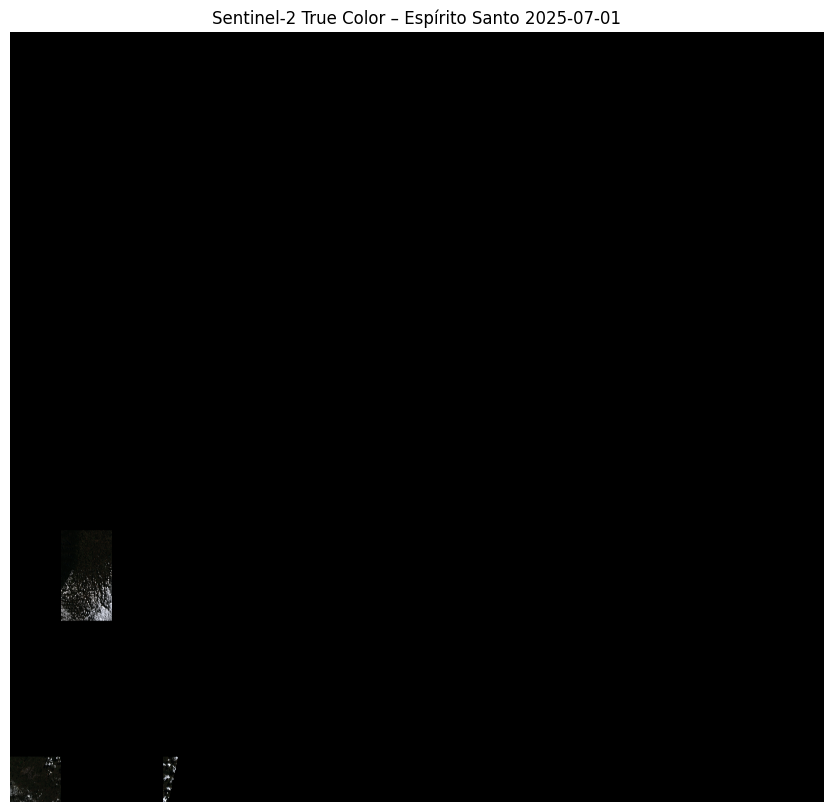

In [28]:
# Load each true color tile, mosaic them using geospatial metadata, and preview the full scene.
true_color_paths = sorted(download_root.glob('tile-*/**/true_color.tif*'))
if not true_color_paths:
    raise RuntimeError('Run the download cell first so true_color.tif files exist.')
datasets = [rasterio.open(path) for path in true_color_paths]
try:
    mosaic, mosaic_transform = merge(datasets)
finally:
    for dataset in datasets:
        dataset.close()
mosaic_rgb = mosaic.transpose(1, 2, 0)
max_val = mosaic_rgb.max()
if max_val > 1:
    mosaic_rgb = mosaic_rgb / max_val
plt.figure(figsize=(12, 10))
plt.imshow(mosaic_rgb)
plt.title('Sentinel-2 True Color – Espírito Santo 2025-07-01')
plt.axis('off')


In [2]:
# Load each true color tile, mosaic them using geospatial metadata, and preview the full scene.
true_color_paths = sorted(download_root.glob('tile-*/**/nir.tif*'))
if not true_color_paths:
    raise RuntimeError('Run the download cell first so nir.tif files exist.')
datasets = [rasterio.open(path) for path in true_color_paths]
try:
    mosaic, mosaic_transform = merge(datasets)
finally:
    for dataset in datasets:
        dataset.close()
mosaic_rgb = mosaic.transpose(1, 2, 0)
max_val = mosaic_rgb.max()
if max_val > 1:
    mosaic_rgb = mosaic_rgb / max_val
plt.figure(figsize=(12, 10))
plt.imshow(mosaic_rgb)
plt.title('Sentinel-2 NIR – Espírito Santo 2025-07-01')
plt.axis('off')

(np.float64(-0.5), np.float64(32175.5), np.float64(30463.5), np.float64(-0.5))

: 